In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [43]:
np.random.seed(42)
n_healthy=500
n_faulty=500

healthy=pd.DataFrame({
    'accel_x': np.random.normal(0.5,0.1,n_healthy),
    'accel_y': np.random.normal(0.5,0.1,n_healthy),
    'accel_z': np.random.normal(9.8,0.2,n_healthy),
    'gyro_x': np.random.normal(0.0,0.1,n_healthy),
    'gyro_y': np.random.normal(0.0,0.1,n_healthy),
    'vibration': np.random.normal(0.2,0.05,n_healthy),
    'temperature': np.random.normal(35.0,2.0,n_healthy),
    'label': 0
})

faulty=pd.DataFrame({
    'accel_x': np.random.normal(2.5,0.8,n_faulty),
    'accel_y': np.random.normal(2.5,0.8,n_faulty),
    'accel_z': np.random.normal(9.8,1.2,n_faulty),
    'gyro_x': np.random.normal(0.0,1.5,n_faulty),
    'gyro_y': np.random.normal(0.0,1.5,n_faulty),
    'vibration': np.random.normal(1.8,0.4,n_faulty),
    'temperature': np.random.normal(71.0,8.0,n_faulty),
    'label': 1
})

df=pd.concat([healthy,faulty], ignore_index=True)
df=df.sample(frac=1,random_state=42).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nHealthy vs Faulty count:")
print(df['label'].value_counts())
df.head()

Dataset shape: (1000, 8)

Healthy vs Faulty count:
label
1    500
0    500
Name: count, dtype: int64


,accel_x,accel_y,accel_z,gyro_x,gyro_y,vibration,temperature,label
0,0.505383,1.361054,11.089200,-1.102675,-0.992312,1.959691,70.400588,1
1,2.372510,2.222158,9.840810,1.803865,2.118040,1.821011,73.655348,1
2,1.928255,1.026482,10.422645,-0.152992,0.507536,1.713391,57.315173,1
3,2.211969,2.510263,11.578353,0.409516,-0.082168,1.857371,77.665262,1
4,0.387536,0.521915,9.911246,0.223130,0.153793,0.217923,34.193848,0


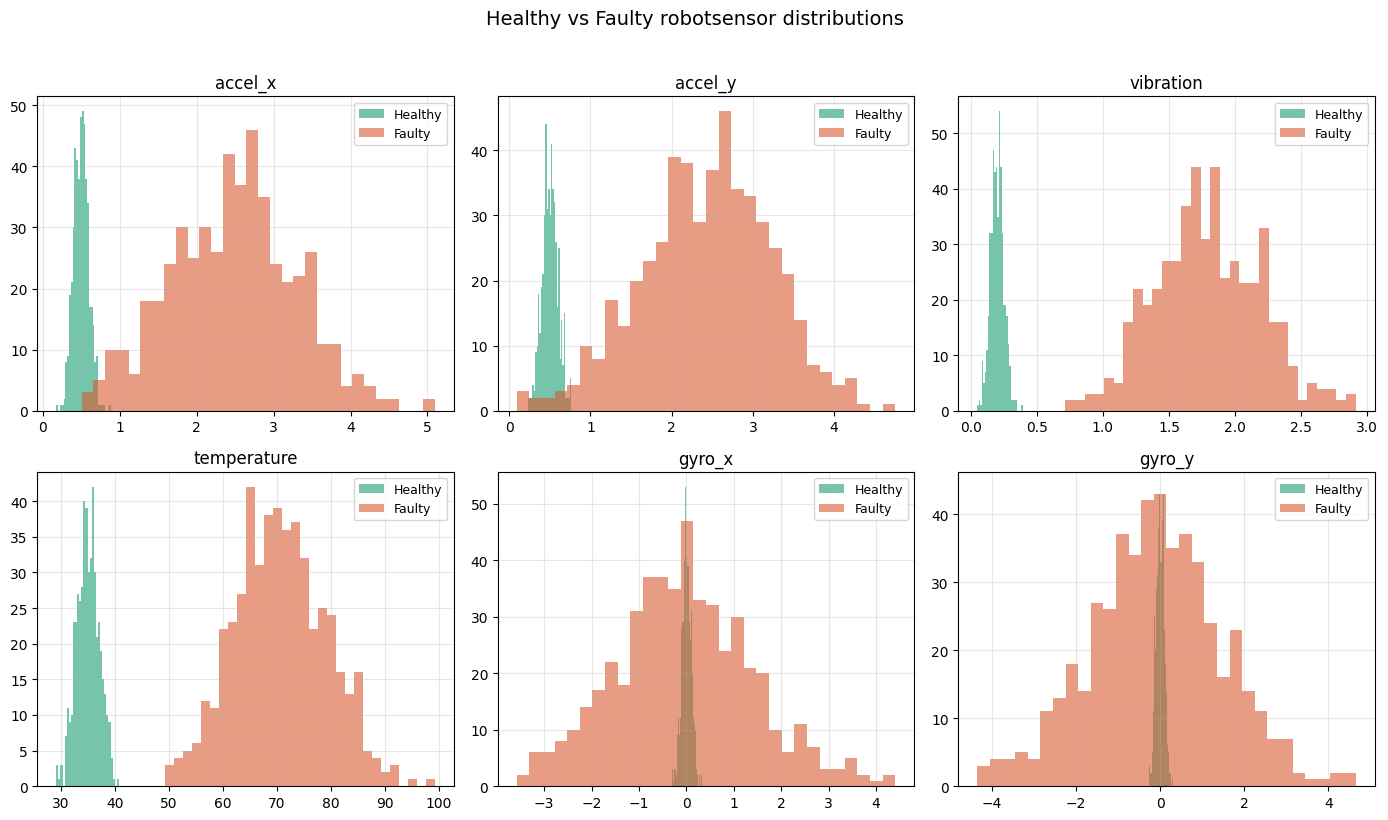

In [44]:
fig,axes=plt.subplots(2,3,figsize=(14,8))

features=['accel_x','accel_y', 'vibration','temperature','gyro_x','gyro_y',]

for i, feature in enumerate(features):
  row=i//3
  col=i%3 # Changed from col=1+i%3

  healthy_data=df[df['label']==0][feature]
  faulty_data=df[df['label']==1][feature]

  axes[row,col].hist(healthy_data,bins=30,alpha=0.6,
                     color='#1D9E75',label='Healthy')
  axes[row,col].hist(faulty_data,bins=30,alpha=0.6,
                   color='#D85A30',label='Faulty')
  axes[row,col].set_title(f'{feature}')
  axes[row,col].legend(fontsize=9)
  axes[row,col].grid(True,alpha=0.3)

plt.suptitle('Healthy vs Faulty robotsensor distributions',
             fontsize=14,y=1.02)
plt.tight_layout()
plt.savefig('plot1_distribution.png',dpi=150)
plt.show()


In [45]:
x=df.drop('label',axis=1)
y=df['label']

print("Features shape:", x.shape)
print("Labels shape:", y.shape)
print("\nFeatures columns:",list(x.columns))

x_train,x_test,y_train,y_test=train_test_split(
    x,y, # Corrected: y should be passed as the second argument
test_size=0.2,
    random_state=42
    )

print(f"\nTrain set size: {len(x_train)}rows")
print(f"Testing set size: {len(x_test)}rows")

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

print("\nData is scaled and ready for ML!")

Features shape: (1000, 7)
Labels shape: (1000,)

Features columns: ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'vibration', 'temperature']

Train set size: 800rows
Testing set size: 200rows

Data is scaled and ready for ML!


In [46]:
dt_model=DecisionTreeClassifier(random_state=42)
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
knn_model=KNeighborsClassifier(n_neighbors=5)

dt_model.fit(x_train_scaled, y_train)
rf_model.fit(x_train_scaled, y_train)
knn_model.fit(x_train_scaled, y_train)

print("All 3 models trained successfully!")
print("\nmodels trained:")
print(" - Decision Tree")
print(" - Random Forest(100 trees)")
print(" - K-Nearest Neighbors(k=5)")

All 3 models trained successfully!

models trained:
 - Decision Tree
 - Random Forest(100 trees)
 - K-Nearest Neighbors(k=5)


In [47]:
models={
    'Decision Tree':dt_model,
    'Random Forest':rf_model,
    'K-Nearest Neighbors':knn_model
}

results={}

print("=" * 50)
print("MODEL COMPARISON RESULTS")
print("="* 50 )

for name,model in models.items():
  predictions=model.predict(x_test_scaled)
  accuracy=accuracy_score(y_test,predictions)
  results[name]=accuracy

  print(f"\n{name}")
  print(f" Accuracy: {accuracy*100:.2f}%")
  print(f"Correct prediction: {int(accuracy*len(y_test))} out of {len(y_test)}")

best_model=max(results,key=results.get)
print(f"\nBest model: {best_model} ({results[best_model]*100:.2f}%)")



MODEL COMPARISON RESULTS

Decision Tree
 Accuracy: 100.00%
Correct prediction: 200 out of 200

Random Forest
 Accuracy: 100.00%
Correct prediction: 200 out of 200

K-Nearest Neighbors
 Accuracy: 100.00%
Correct prediction: 200 out of 200

Best model: Decision Tree (100.00%)


In [48]:
best_prediction=models[best_model].predict(x_test_scaled)

print(f"Detailed report for: {best_model}")
print("="*50)
print(classification_report(y_test,best_prediction,
      target_names=['Healthy','Faulty']))

Detailed report for: Decision Tree
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       100
      Faulty       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



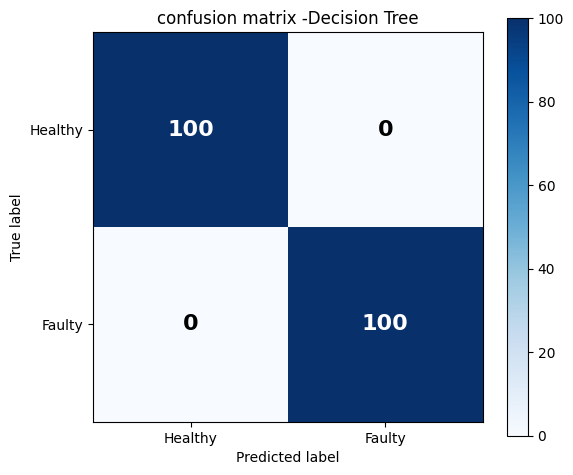


How to read this:
 Top-left: correctly identified healthy robots
 Bottom-right: correctly identified faulty robots
 Top-right: healthy robots wrongly flagged as faulty
 Bottom-left: faulty robots missed(most dangerous!)


In [49]:
cm=confusion_matrix(y_test,best_prediction)

fig,ax=plt.subplots(figsize=(6,5))
im=ax.imshow(cm,cmap='Blues')
plt.colorbar(im)

categories=['Healthy', 'Faulty']
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(categories)
ax.set_yticklabels(categories)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'confusion matrix -{best_model}')

for i in range(2):
  for j in range(2):
    ax.text(j,i,str(cm[i,j]),
            ha='center',va='center',
            fontsize=16,fontweight='bold',
            color='white' if cm[i,j]>cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('plot2_confusion_matrix.png',dpi=150)
plt.show()

print("\nHow to read this:")
print(f" Top-left: correctly identified healthy robots")
print(f" Bottom-right: correctly identified faulty robots")
print(f" Top-right: healthy robots wrongly flagged as faulty")
print(f" Bottom-left: faulty robots missed(most dangerous!)")

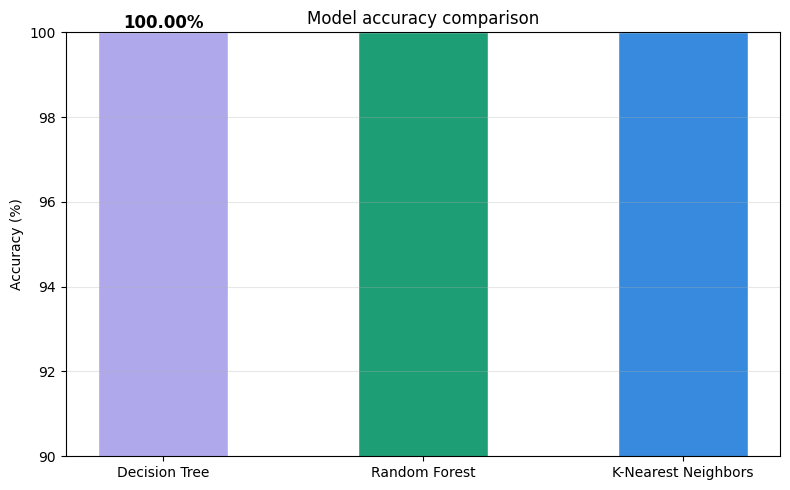

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [50]:


fig, ax=plt.subplots(figsize=(8,5))

model_names=list(results.keys())
accuracies=[v*100 for v in results.values()]
colors=['#AFA9EC','#1D9E75','#378ADD']

bars=ax.bar(model_names,accuracies,color=colors,
            edgecolor='white',width=0.5)

ax.set_ylim([90,100])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model accuracy comparison')
ax.grid(True,alpha=0.3,axis='y')

for bar,acc in zip(bars,accuracies):
  ax.text(bar.get_x()+bar.get_width()/2,
          bar.get_height()+0.01,
          f'{acc:.2f}%',
          ha='center',va='bottom',
          fontsize=12,fontweight='bold')

  plt.tight_layout()
  plt.savefig('plot3_model_comparison.png',dpi=150)
  plt.show()

In [51]:
print("LIVE FAULT DETECTION TEST")
print("="*40)

new_healthy_robot=np.array([[0.48,0.52,9.81,0.02,-0.01,0.19,34.5]])
new_faulty_robot=np.array([[2.80,2.60,9.75,1.45,-1.60,1.95,78.3]])

new_healthy_scaled=scaler.transform(new_healthy_robot)
new_faulty_scaled=scaler.transform(new_faulty_robot)

best=models[best_model]

h_pred=best.predict(new_healthy_scaled)[0]
f_pred=best.predict(new_faulty_scaled)[0]

h_prob=best.predict_proba(new_healthy_scaled)[0]
f_prob=best.predict_proba(new_faulty_scaled)[0]

print(f"\nRobot A (should be HEALTHY):")
print(f" Prediction: {'FAULTY'if h_pred==1 else 'HEALTHY'}")
print(f" Confidence: {max(h_prob)*100:.1f}%")

print(f"\nRobot B (should be FAULTY):")
print(f" Prediction: {'FAULTY' if f_pred==1 else 'HEALTHY'}")
print(f" Confidence: {max(f_prob)*100:.1f}%")

LIVE FAULT DETECTION TEST

Robot A (should be HEALTHY):
 Prediction: HEALTHY
 Confidence: 100.0%

Robot B (should be FAULTY):
 Prediction: FAULTY
 Confidence: 100.0%


In [52]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
files=[
    'plot1_distribution.png',
    'plot2_confusion_matrix.png',
    'plot3_model_comparison.png'
]

for f in files:
  shutil.copy(f,f'/content/drive/MyDrive/{f}')

  print("All files saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files saved to Google Drive!
All files saved to Google Drive!
All files saved to Google Drive!


In [53]:
print("="*50)
print("ROBOT FAULT DETECTION-PROJECT SUMMARY")
print("="*50)
print(f"\nDataset: 1000 robot sensor readings")
print(f" (500 healthy, 500 faulty)")
print(f"Features: 6 sensors(accel x/y/z,gyro x/y, vibration,temperature)")
print(f"Models tested:Decision Tree, Random Forest, KNN")
print(f"\nResults")
for name, acc in results.items():
  print(f"{name}: {acc*100:.2f}%")
print(f"\nBest model: {best_model}({results[best_model]*100:2f}% accuracy)")
print(f"\nCharts saved:")
print(f" plot1_distribution.png    - healthy vs faulty sensor patterns")
print(f" plot2_confusion_matrix.png- where the model got it rght/wrong")
print(f" plot3_model_comparison.png -accurate comparison of all 3 models")
print(f"\nTools used : Numpy, Pandas, Matplotlib, Scikit-learn")


ROBOT FAULT DETECTION-PROJECT SUMMARY

Dataset: 1000 robot sensor readings
 (500 healthy, 500 faulty)
Features: 6 sensors(accel x/y/z,gyro x/y, vibration,temperature)
Models tested:Decision Tree, Random Forest, KNN

Results
Decision Tree: 100.00%
Random Forest: 100.00%
K-Nearest Neighbors: 100.00%

Best model: Decision Tree(100.000000% accuracy)

Charts saved:
 plot1_distribution.png    - healthy vs faulty sensor patterns
 plot2_confusion_matrix.png- where the model got it rght/wrong
 plot3_model_comparison.png -accurate comparison of all 3 models

Tools used : Numpy, Pandas, Matplotlib, Scikit-learn
